In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [2]:
dataset = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 31232
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5205
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5206
    })
})

# Data Analysis

In [3]:
train_data = pd.DataFrame(dataset["train"])
valid_data = pd.DataFrame(dataset["validation"])
train_data = pd.concat([train_data, valid_data], ignore_index=True)
test_data = pd.DataFrame(dataset["test"])
train_data.head()

,id,text,label,sentiment
0,9536,"Cooking microwave pizzas, yummy",2,positive
1,6135,Any plans of allowing sub tasks to show up in ...,1,neutral
2,17697,"I love the humor, I just reworded it. Like sa...",2,positive
3,14182,naw idk what ur talkin about,1,neutral
4,17840,That sucks to hear. I hate days like that,0,negative


In [4]:
train_data["text"]

,text
0,"Cooking microwave pizzas, yummy"
1,Any plans of allowing sub tasks to show up in ...
2,"I love the humor, I just reworded it. Like sa..."
3,naw idk what ur talkin about
4,That sucks to hear. I hate days like that
...,...
36432,Not sure what happened but now I have to hit t...
36433,"Pretty good app, lets you organize tasks by ca..."
36434,This app is a piece of sh**. It won't sync my ...
36435,": Very interested. However, low carbs for the ..."


In [5]:
pd.crosstab(train_data["label"],train_data["sentiment"]) # correlates

sentiment,negative,neutral,positive
label,,,
0,10622,0,0
1,0,13577,0
2,0,0,12238


In [6]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36437 entries, 0 to 36436
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         36437 non-null  int64 
 1   text       36437 non-null  object
 2   label      36437 non-null  int64 
 3   sentiment  36437 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5206 entries, 0 to 5205
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         5206 non-null   int64 
 1   text       5205 non-null   object
 2   label      5206 non-null   int64 
 3   sentiment  5206 non-null   object
dtypes: int64(2), object(2)
memory usage: 162.8+ KB


<Figure size 600x400 with 0 Axes>

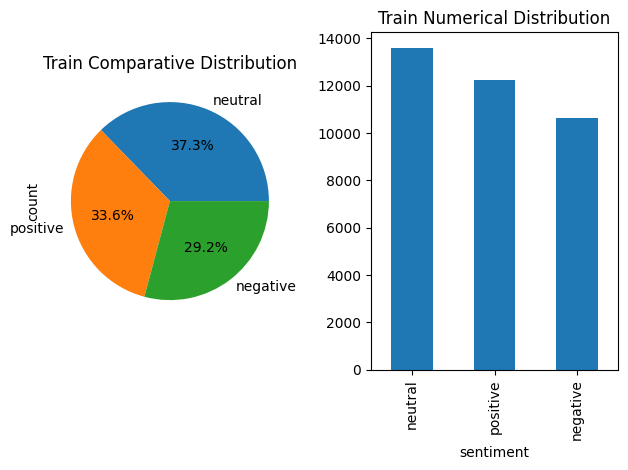

In [7]:
plt.figure(figsize=(6, 4))
fig, axs = plt.subplots(1, 2)
train_data["sentiment"].value_counts().plot(kind="pie", ax=axs[0], autopct='%1.1f%%', title="Train Comparative Distribution")
train_data["sentiment"].value_counts().plot(kind="bar", ax=axs[1], title="Train Numerical Distribution")
plt.tight_layout()

<Figure size 600x400 with 0 Axes>

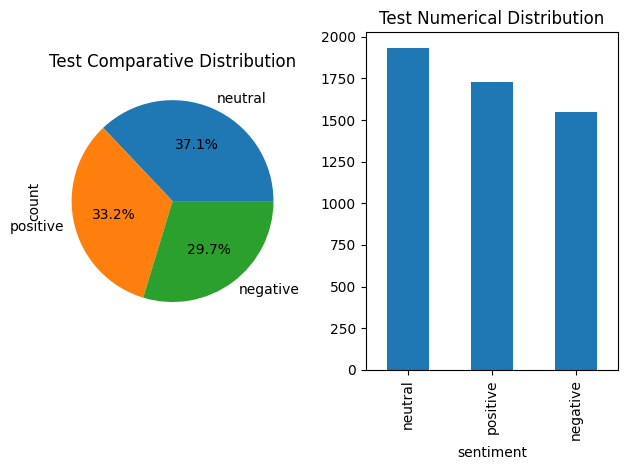

In [8]:
plt.figure(figsize=(6, 4))
fig, axs = plt.subplots(1, 2)
test_data["sentiment"].value_counts().plot(kind="pie", ax=axs[0], autopct='%1.1f%%', title="Test Comparative Distribution")
test_data["sentiment"].value_counts().plot(kind="bar", ax=axs[1], title="Test Numerical Distribution")
plt.tight_layout()

In [9]:
print(test_data.shape)
test_data = test_data.dropna()
print(test_data.shape)

(5206, 4)
(5205, 4)


# Data Preprocessing

In [23]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [12]:
slang_dict = {
    r'\bidk\b': 'i do not know',
    r'\bnvm\b': 'nevermind',
    r'\bur\b': 'you are',
    r'\bnah\b': 'no',
    r'\bnaw\b': 'no',
    r'\bok\b': 'okay',
    r'\bsh\*\*\b': 'shit'
}

def clean_and_lemmatize(text):
    text = text.lower().strip()

    for pattern, replacement in slang_dict.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokenlar = word_tokenize(text)

    temiz_tokenlar = [
        lemmatizer.lemmatize(token)
        for token in tokenlar
        if token.isalnum() and token not in stop_words
    ]

    return " ".join(temiz_tokenlar)

In [13]:
train_data["clean_text"] = train_data["text"].apply(clean_and_lemmatize)
train_data["clean_text"].head()

test_data["clean_text"] = test_data["text"].apply(clean_and_lemmatize)
test_data["clean_text"].head()

,clean_text
0,getting cd ready tour
1,mc happy mother day mom love yah
2,year graduation pretty sure ready
3,chip sale
4,great organising work life balance


In [14]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", min_df=0.01, max_df=0.99)

In [15]:
X_train, y_train, X_test, y_test = train_data["clean_text"], train_data["sentiment"], test_data["clean_text"], test_data["sentiment"]

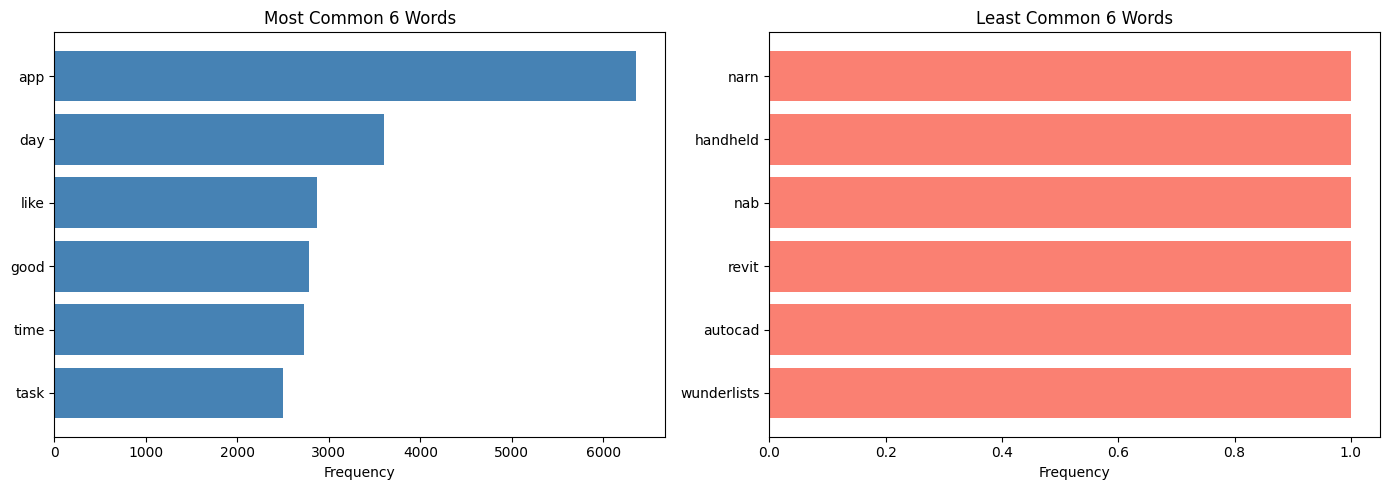

In [24]:
all_words = " ".join(train_data["clean_text"]).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.most_common(), columns=["word", "frequency"])

top_6 = word_freq_df.head(6)
bottom_6 = word_freq_df.tail(6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_6["word"], top_6["frequency"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Most Common 6 Words")
axes[0].set_xlabel("Frequency")

axes[1].barh(bottom_6["word"], bottom_6["frequency"], color="salmon")
axes[1].invert_yaxis()
axes[1].set_title("Least Common 6 Words")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

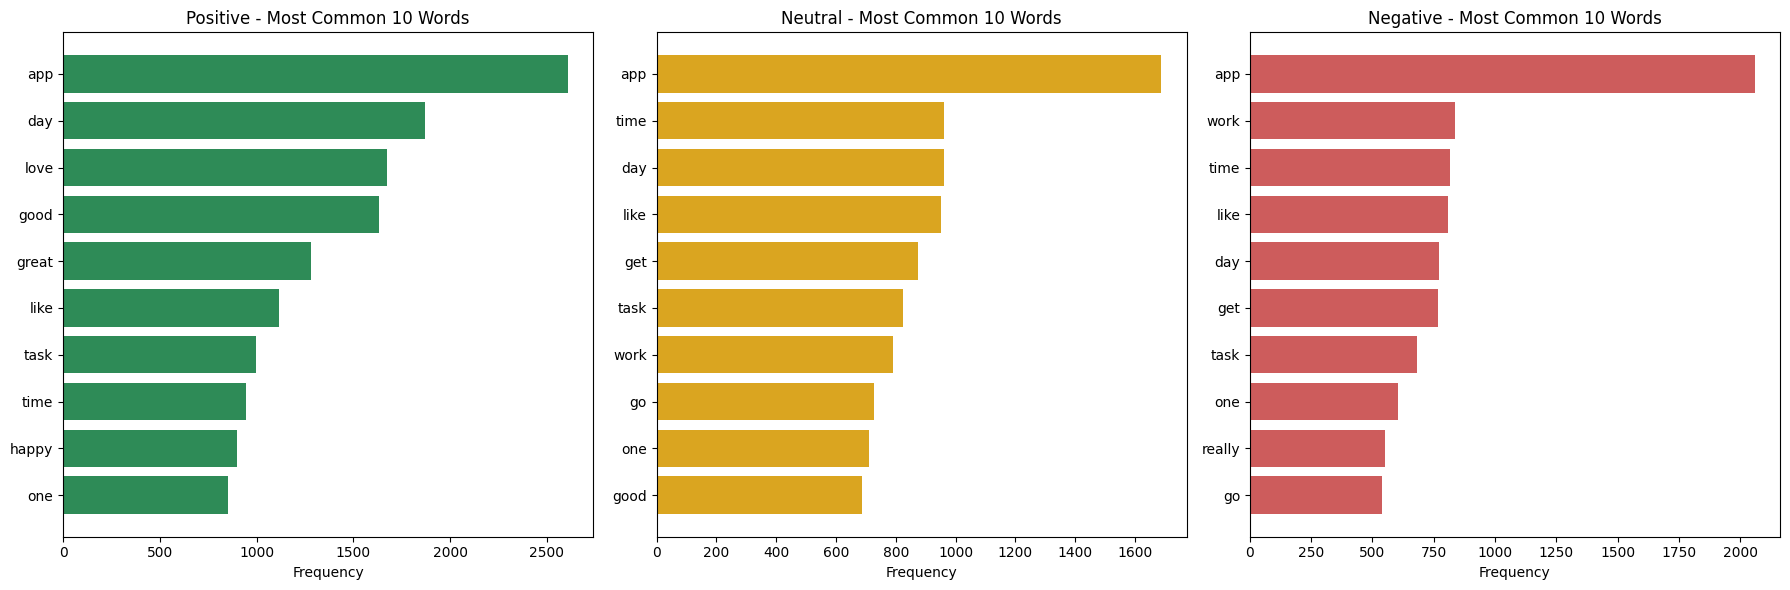

In [27]:
sentiment_word_freq = {}

for sentiment in train_data["sentiment"].unique():
    words = " ".join(train_data[train_data["sentiment"] == sentiment]["clean_text"]).split()
    sentiment_word_freq[sentiment] = Counter(words)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = ["positive", "neutral", "negative"]
colors = ["seagreen", "goldenrod", "indianred"]

for ax, sentiment, color in zip(axes, sentiments, colors):
    top_10 = sentiment_word_freq[sentiment].most_common(10)
    kelimeler = [w[0] for w in top_10]
    frekanslar = [w[1] for w in top_10]

    ax.barh(kelimeler, frekanslar, color=color)
    ax.invert_yaxis()
    ax.set_title(f"{sentiment.capitalize()} - Most Common 10 Words")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

In [28]:
X_train_vectorized = tfidf_vectorizer.fit_transform(X_train)

# matrix vis
normal_matrix = X_train_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,able,add,amazing,app,apps,awesome,bad,bed,best,better,...,want,way,week,weekend,widget,wish,work,working,yeah,year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.783663,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [29]:
X_test_vectorized = tfidf_vectorizer.transform(X_test)

# matrix vis
normal_matrix = X_test_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,able,add,amazing,app,apps,awesome,bad,bed,best,better,...,want,way,week,weekend,widget,wish,work,working,yeah,year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.542293
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.499945,0.0,0.0,0.000000


# ML Model Build

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## LogisticRegression

In [31]:
best_model = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring='accuracy'
)
best_model.fit(X_train_vectorized, y_train)

print(f"Best Parameters: {best_model.best_params_}")
print(f"Best Score: {best_model.best_score_}")

Best Parameters: {'C': 1000}
Best Score: 0.5777644187497185


In [32]:
y_pred = best_model.predict(X_test_vectorized)
accuracy_score(y_test, y_pred)

0.5692603266090298

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.58      0.35      0.44      1546
     neutral       0.49      0.72      0.58      1929
    positive       0.70      0.60      0.65      1730

    accuracy                           0.57      5205
   macro avg       0.59      0.56      0.56      5205
weighted avg       0.59      0.57      0.56      5205



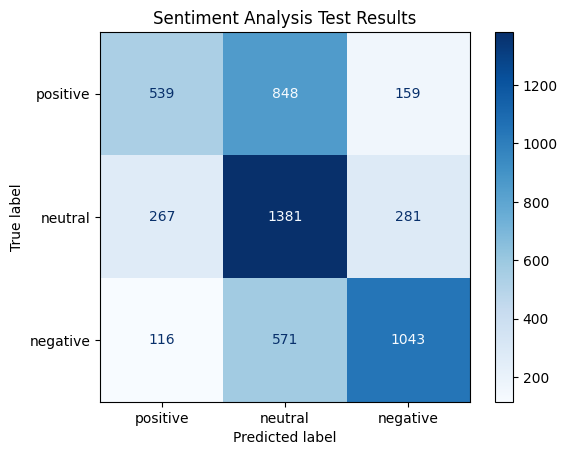

In [35]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_vectorized,
    y_test,
    display_labels=y_train.unique(),
    cmap='Blues'
)

plt.title('Sentiment Analysis Test Results')
plt.show()

## Decision Tree

In [36]:
param_grid = {
    "max_depth": np.arange(45, 64, 3),
    "min_samples_split" : np.logspace(start=5, stop=9, num=8, base=2, dtype=int)
}
best_model = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    return_train_score=True,
    verbose=1
)
best_model.fit(X_train_vectorized, y_train)
results = pd.DataFrame(best_model.cv_results_)

best_index = best_model.best_index_
train_score = results.loc[best_index, 'mean_train_score']
val_score = results.loc[best_index, 'mean_test_score']

print(f"Best Parameters: {best_model.best_params_}")
print(f"Train Score: {train_score:.4f}")
print(f"Validation Score: {val_score:.4f}")

Fitting 5 folds for each of 56 candidates, totalling 280 fits
Best Parameters: {'max_depth': np.int64(63), 'min_samples_split': np.int64(512)}
Train Score: 0.5821
Validation Score: 0.5513


In [37]:
y_pred = best_model.predict(X_test_vectorized)
accuracy_score(y_test, y_pred)

0.5556195965417867

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.56      0.35      0.43      1546
     neutral       0.49      0.69      0.57      1929
    positive       0.66      0.59      0.62      1730

    accuracy                           0.56      5205
   macro avg       0.57      0.54      0.54      5205
weighted avg       0.57      0.56      0.55      5205



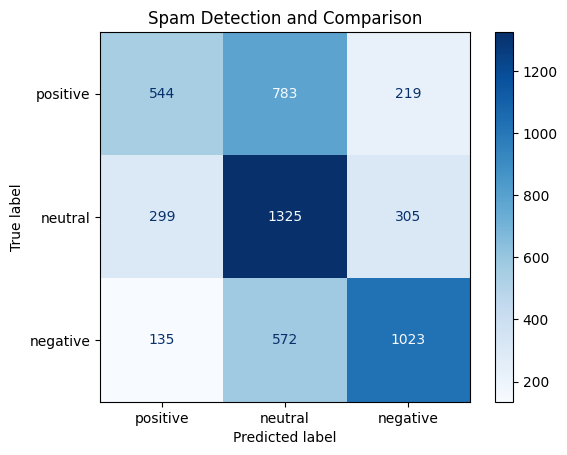

In [39]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_vectorized,
    y_test,
    display_labels=y_train.unique(),
    cmap='Blues'
)

plt.title('Sentiment Analysis Test Results')
plt.show()